# 🏦 Bank Fraud Detection & Risk Analytics

## End-to-End Fraud Detection Analysis

This project analyzes banking transactions to identify fraudulent patterns and compare statistical anomaly detection and machine learning methods.

### Objectives

- Explore transaction and customer data
- Identify unusual transaction patterns
- Detect potential fraudulent transactions
- Compare anomaly detection methods
- Build supervised machine learning models
- Evaluate model performance

### Tools

- Python
- Pandas
- NumPy
- SciPy
- Scikit-learn
- XGBoost
- Matplotlib


## 🎯 Business Problem

Fraudulent transactions can cause significant financial losses for banks.

The objective of this analysis is to identify transactions that may be associated with fraud and evaluate different statistical and machine learning approaches.

The analysis focuses on:

- Transaction amount
- Transaction time
- Night transactions
- Weekend transactions
- Merchant category
- Customer income
- Income-to-transaction relationship

The key business priority is to reduce false negative predictions, because missed fraudulent transactions can result in financial loss.

In [1]:
!pip install pandas numpy matplotlib scipy scikit-learn xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
fraud_labels = pd.read_csv("fraud_labels.csv")

In [ ]:
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Fraud Labels:", fraud_labels.shape)

In [ ]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nFRAUD LABELS")
print(fraud_labels.columns.tolist())

In [87]:
customers.head()

,customer_id,age,income,segment
0,C0001,43,28663,Basic
1,C0002,36,31173,Basic
2,C0003,45,73097,Standard
3,C0004,56,11732,Student
4,C0005,35,32949,Basic


In [88]:
transactions.head()

,tx_id,customer_id,amount,timestamp,merchant_category,Unnamed: 5
0,TX003996,C0014,2312.19,2024-06-22 16:36:50,Travel,501.0
1,TX002547,C0367,2303.27,2024-09-08 08:03:53,Travel,NaN
2,TX002143,C0471,2291.00,2024-12-27 10:26:28,Travel,NaN
3,TX004351,C0442,2254.92,2024-01-01 00:48:32,Travel,NaN
4,TX005050,C0327,2068.52,2024-04-19 06:15:04,Travel,NaN


In [89]:
fraud_labels.head()

,tx_id,is_fraud
0,TX004351,1
1,TX003518,0
2,TX005229,0
3,TX004102,0
4,TX000395,0


In [90]:
df = transactions.merge(
    customers,
    on="customer_id",
    how="left"
)

In [91]:
df = df.merge(
    fraud_labels,
    on="tx_id",
    how="left"
)

In [92]:
df.head()

,tx_id,customer_id,amount,timestamp,merchant_category,Unnamed: 5,age,income,segment,is_fraud
0,TX003996,C0014,2312.19,2024-06-22 16:36:50,Travel,501.0,18,23653,Student,0
1,TX002547,C0367,2303.27,2024-09-08 08:03:53,Travel,NaN,40,17155,Student,0
2,TX002143,C0471,2291.00,2024-12-27 10:26:28,Travel,NaN,34,54590,Standard,0
3,TX004351,C0442,2254.92,2024-01-01 00:48:32,Travel,NaN,37,50462,Standard,1
4,TX005050,C0327,2068.52,2024-04-19 06:15:04,Travel,NaN,51,35070,Basic,0


In [93]:
df.columns.tolist()

['tx_id',
 'customer_id',
 'amount',
 'timestamp',
 'merchant_category',
 'Unnamed: 5',
 'age',
 'income',
 'segment',
 'is_fraud']

## 1. Data Understanding

The three source tables are combined using customer ID and transaction ID.

The resulting dataset contains customer information, transaction details, and fraud labels.

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tx_id              8000 non-null   str    
 1   customer_id        8000 non-null   str    
 2   amount             8000 non-null   float64
 3   timestamp          8000 non-null   str    
 4   merchant_category  8000 non-null   str    
 5   Unnamed: 5         1 non-null      float64
 6   age                8000 non-null   int64  
 7   income             8000 non-null   int64  
 8   segment            8000 non-null   str    
 9   is_fraud           8000 non-null   int64  
dtypes: float64(2), int64(3), str(5)
memory usage: 625.1 KB


In [95]:
df.shape

(8000, 10)

In [96]:
df.isnull().sum()

tx_id                   0
customer_id             0
amount                  0
timestamp               0
merchant_category       0
Unnamed: 5           7999
age                     0
income                  0
segment                 0
is_fraud                0
dtype: int64

In [97]:
df["is_fraud"].value_counts()

is_fraud
0    7503
1     497
Name: count, dtype: int64

In [98]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    93.7875
1     6.2125
Name: proportion, dtype: float64

## 2. Feature Engineering

Transaction time and customer information are transformed into additional features that can help machine learning models identify fraud patterns.

In [99]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [100]:
df["timestamp"].head()

0   2024-06-22 16:36:50
1   2024-09-08 08:03:53
2   2024-12-27 10:26:28
3   2024-01-01 00:48:32
4   2024-04-19 06:15:04
Name: timestamp, dtype: datetime64[us]

In [101]:
df["hour"] = df["timestamp"].dt.hour

In [102]:
df[["timestamp", "hour"]].head()

,timestamp,hour
0,2024-06-22 16:36:50,16
1,2024-09-08 08:03:53,8
2,2024-12-27 10:26:28,10
3,2024-01-01 00:48:32,0
4,2024-04-19 06:15:04,6


In [103]:
df["is_weekend"] = (
    df["timestamp"].dt.dayofweek >= 5
).astype(int)

In [104]:
df[["timestamp", "is_weekend"]].head()

,timestamp,is_weekend
0,2024-06-22 16:36:50,1
1,2024-09-08 08:03:53,1
2,2024-12-27 10:26:28,0
3,2024-01-01 00:48:32,0
4,2024-04-19 06:15:04,0


In [105]:
df["is_night"] = (
    df["hour"].between(0, 5)
).astype(int)

In [106]:
df[["hour", "is_night"]].head(10)

,hour,is_night
0,16,0
1,8,0
2,10,0
3,0,1
4,6,0
5,1,1
6,2,1
7,8,0
8,5,1
9,9,0


In [107]:
(df["income"] == 0).sum()

np.int64(0)

In [108]:
df["income_ratio"] = df["amount"] / df["income"]

In [109]:
df[["amount", "income", "income_ratio"]].head()

,amount,income,income_ratio
0,2312.19,23653,0.097755
1,2303.27,17155,0.134262
2,2291.00,54590,0.041967
3,2254.92,50462,0.044686
4,2068.52,35070,0.058983


In [110]:
le = LabelEncoder()

df["category_encoded"] = le.fit_transform(
    df["merchant_category"]
)

In [111]:
df[["merchant_category", "category_encoded"]].head()

,merchant_category,category_encoded
0,Travel,9
1,Travel,9
2,Travel,9
3,Travel,9
4,Travel,9


## 3. Model Features

The following features are used to identify unusual transaction patterns:

- Transaction amount
- Transaction hour
- Weekend indicator
- Night transaction indicator
- Merchant category
- Transaction amount relative to customer income

In [112]:
features = [
    "amount",
    "hour",
    "is_weekend",
    "is_night",
    "category_encoded",
    "income_ratio"
]

In [113]:
df[features].head()

,amount,hour,is_weekend,is_night,category_encoded,income_ratio
0,2312.19,16,1,0,9,0.097755
1,2303.27,8,1,0,9,0.134262
2,2291.00,10,0,0,9,0.041967
3,2254.92,0,0,1,9,0.044686
4,2068.52,6,0,0,9,0.058983


In [114]:
transactions = transactions.drop(columns=["Unnamed: 5"])

In [115]:
transactions.columns.tolist()

['tx_id', 'customer_id', 'amount', 'timestamp', 'merchant_category']

## 4. IQR Anomaly Detection

The Interquartile Range (IQR) method is used to identify unusually high or low transaction amounts.

This method focuses only on transaction amount. Therefore, it may miss fraudulent transactions that have normal transaction amounts but unusual characteristics such as transaction time, merchant category or customer income.

In [116]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 53.77
Q3: 181.8
IQR: 128.03


In [117]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -138.275
Upper bound: 373.845


In [118]:
df["iqr_anomaly"] = (
    (df["amount"] < lower_bound) |
    (df["amount"] > upper_bound)
).astype(int)

In [119]:
df["iqr_anomaly"].value_counts()

iqr_anomaly
0    7107
1     893
Name: count, dtype: int64

In [120]:
print(
    pd.crosstab(
        df["is_fraud"],
        df["iqr_anomaly"]
    )
)

iqr_anomaly     0    1
is_fraud              
0            6711  792
1             396  101


In [121]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df["is_fraud"],
        df["iqr_anomaly"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7503
           1       0.11      0.20      0.15       497

    accuracy                           0.85      8000
   macro avg       0.53      0.55      0.53      8000
weighted avg       0.89      0.85      0.87      8000



## 5. Z-Score Anomaly Detection

Z-Score measures how far a transaction amount is from the average transaction amount in terms of standard deviations.

Transactions with an absolute Z-Score greater than 3 are considered potential anomalies.

In [122]:
df["z_score"] = np.abs(
    stats.zscore(df["amount"])
)

In [123]:
df["z_score"].describe()

count    8000.000000
mean        0.629985
std         0.776655
min         0.000089
25%         0.288377
50%         0.488235
75%         0.625159
max        10.255018
Name: z_score, dtype: float64

In [124]:
df["zscore_anomaly"] = (
    df["z_score"] > 3
).astype(int)

In [125]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
0    7818
1     182
Name: count, dtype: int64

In [126]:
print(
    classification_report(
        df["is_fraud"],
        df["zscore_anomaly"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7503
           1       0.21      0.08      0.11       497

    accuracy                           0.92      8000
   macro avg       0.58      0.53      0.54      8000
weighted avg       0.90      0.92      0.91      8000



## 6. Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm.

It considers multiple transaction characteristics and attempts to isolate unusual observations.

Unlike IQR and Z-Score, the model can consider transaction amount, transaction time, weekend activity, night activity, merchant category and income ratio together.

In [127]:
features = [
    "amount",
    "hour",
    "is_weekend",
    "is_night",
    "category_encoded",
    "income_ratio"
]

X_iforest = df[features].copy()

In [128]:
iforest_model = IsolationForest(
    contamination=0.0621,
    random_state=42
)

In [129]:
df["iforest_anomaly"] = (
    iforest_model.fit_predict(X_iforest) == -1
).astype(int)

In [130]:
df["iforest_anomaly"].value_counts()

iforest_anomaly
0    7503
1     497
Name: count, dtype: int64

In [131]:
print(
    classification_report(
        df["is_fraud"],
        df["iforest_anomaly"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7503
           1       0.13      0.13      0.13       497

    accuracy                           0.89      8000
   macro avg       0.54      0.54      0.54      8000
weighted avg       0.89      0.89      0.89      8000



## 7. Logistic Regression

Logistic Regression is used as a supervised baseline model.

Unlike IQR, Z-Score and Isolation Forest, the model uses the historical `is_fraud` label to learn patterns associated with fraudulent transactions.

Because fraud transactions are usually a minority class, `class_weight='balanced'` is used.

In [132]:
X = df[features]
y = df["is_fraud"]

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [134]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [136]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [137]:
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

In [138]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.95      0.67      0.79      1501
           1       0.09      0.48      0.15        99

    accuracy                           0.66      1600
   macro avg       0.52      0.58      0.47      1600
weighted avg       0.90      0.66      0.75      1600



## 8. Random Forest

Random Forest is an ensemble machine learning algorithm based on multiple decision trees.

It can capture nonlinear relationships between transaction characteristics and fraud.

In [139]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

In [140]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [141]:
y_pred_rf = rf_model.predict(
    X_test
)

In [142]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1501
           1       0.14      0.07      0.09        99

    accuracy                           0.92      1600
   macro avg       0.54      0.52      0.53      1600
weighted avg       0.89      0.92      0.90      1600



## 9. XGBoost

XGBoost is a powerful gradient boosting algorithm commonly used for classification problems.

It builds trees sequentially and attempts to improve the errors made by previous trees.

In [143]:
from xgboost import XGBClassifier

In [144]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [162]:
xgb_model.fit(
    X_train,
    y_train
)

AttributeError: module 'pandas' has no attribute 'util'

In [147]:
y_pred_xgb = xgb_model.predict(
    X_test
)

NotFittedError: need to call fit or load_model beforehand

In [148]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        zero_division=0
    )
)

NameError: name 'y_pred_xgb' is not defined

## 10. Model Comparison

The different fraud detection methods are compared using precision, recall and F1-score.

Recall is particularly important in fraud detection because false negative predictions represent fraudulent transactions that were not detected.

In [149]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [150]:
comparison = pd.DataFrame({
    "Method": [
        "IQR",
        "Z-Score",
        "Isolation Forest",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    
    "Precision": [
        precision_score(df["is_fraud"], df["iqr_anomaly"], zero_division=0),
        precision_score(df["is_fraud"], df["zscore_anomaly"], zero_division=0),
        precision_score(df["is_fraud"], df["iforest_anomaly"], zero_division=0),
        precision_score(y_test, y_pred_logistic, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    
    "Recall": [
        recall_score(df["is_fraud"], df["iqr_anomaly"], zero_division=0),
        recall_score(df["is_fraud"], df["zscore_anomaly"], zero_division=0),
        recall_score(df["is_fraud"], df["iforest_anomaly"], zero_division=0),
        recall_score(y_test, y_pred_logistic, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    
    "F1": [
        f1_score(df["is_fraud"], df["iqr_anomaly"], zero_division=0),
        f1_score(df["is_fraud"], df["zscore_anomaly"], zero_division=0),
        f1_score(df["is_fraud"], df["iforest_anomaly"], zero_division=0),
        f1_score(y_test, y_pred_logistic, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ]
})

comparison

NameError: name 'y_pred_xgb' is not defined

In [151]:
best_recall_method = comparison.loc[
    comparison["Recall"].idxmax()
]

best_recall_method

NameError: name 'comparison' is not defined

## 11. XGBoost Confusion Matrix

The confusion matrix shows how many fraudulent and legitimate transactions were correctly and incorrectly classified.

In [152]:
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm)

NameError: name 'y_pred_xgb' is not defined

In [153]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Fraud", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Not Fraud", "Fraud"]
)

plt.colorbar()

plt.show()

NameError: name 'cm' is not defined

<Figure size 600x500 with 0 Axes>

## 12. Feature Importance

Feature importance helps identify which transaction characteristics contribute most to the Random Forest model's predictions.

In [154]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

importance

amount              0.341259
income_ratio        0.340339
hour                0.170303
category_encoded    0.107100
is_weekend          0.024415
is_night            0.016583
dtype: float64

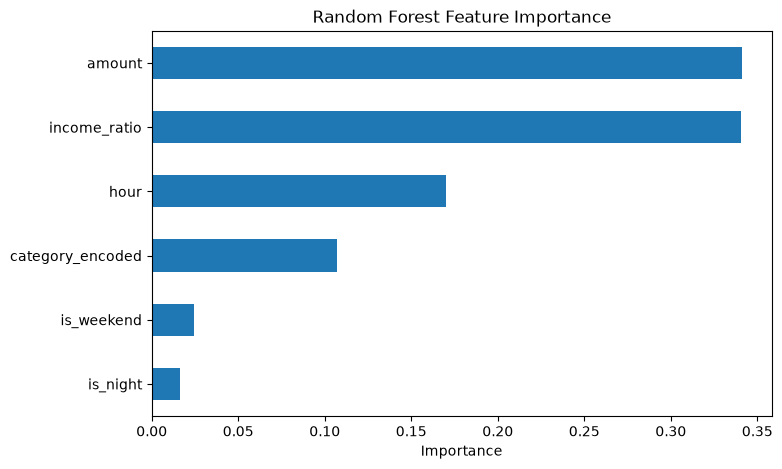

In [155]:
plt.figure(figsize=(8, 5))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

## 13. SHAP Model Interpretation

SHAP is used to interpret how individual features influence the XGBoost model's predictions.

This helps move from simply predicting fraud to understanding why the model considers a transaction risky.

In [156]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [157]:
!pip install "numpy<2.5" --force-reinstall

  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
import shap

In [161]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

NotFittedError: need to call fit or load_model beforehand

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features
)

## 14. Business Recommendations

The analysis demonstrates that fraud detection can be approached using both statistical anomaly detection and supervised machine learning.

Key business recommendations include:

1. Monitor unusually high transaction amounts.
2. Pay additional attention to transactions occurring during unusual hours.
3. Monitor merchant categories with elevated fraud rates.
4. Investigate customers with repeated fraudulent transactions.
5. Use machine learning models as a risk-scoring layer.
6. Prioritize recall when the cost of missing fraud is higher than the cost of reviewing legitimate transactions.

The final model selection should consider recall, precision, F1-score and the operational cost of false positives and false negatives.